# DM_G4_P0008_set_covering_facility_answer

## 0. 정답본 범위
- Gate: G4
- Phase: P0008
- Topic: set covering, max coverage, capacitated facility location
- Problem notebook: DM_G4_P0008_set_covering_facility.ipynb
- Correct answers included: Yes
- Output language: Korean

## 1. 핵심 기준표
| 기준 | 정답 판단 |
|---|---|
| coverage matrix | 행 `i`는 수요구역, 열 `j`는 후보지, `A_ij=1`은 커버 가능이다. |
| set covering | 모든 행이 적어도 한 번 커버되도록 `Ax >= 1`을 둔다. |
| set partitioning | 각 행이 정확히 한 번만 배정되도록 `Ax = 1`을 둔다. |
| set packing | 겹침을 금지하려면 `Ax <= 1`을 둔다. |
| max coverage | 설치 변수 `x_j`와 혜택 변수 `y_i`를 분리해 중복계산을 막는다. |

## 2. 문항별 정답

### 문제 1 정답 — 야간 응급 AED 설치
**변수와 목적함수**
- `x_j=1`이면 후보지 `j`에 AED를 설치, `0`이면 미설치.
- 동일 비용이면 Minimize `x1+x2+x3+x4+x5+x6`.
- 비용 고려 시 Minimize `8x1+7x2+6x3+9x4+5x5+6x6`.

**covering constraints**
- 구역 1: `x1+x3 >= 1`
- 구역 2: `x1+x2 >= 1`
- 구역 3: `x2+x3+x5 >= 1`
- 구역 4: `x3+x4 >= 1`
- 구역 5: `x4+x5+x6 >= 1`
- 구역 6: `x2+x5 >= 1`
- 구역 7: `x4+x6 >= 1`
- 구역 8: `x1+x6 >= 1`
- 일반형: `Ax >= 1`, `x_j in {0,1}`.

**해석과 검산 기준 최적해**
- 우변 1은 “각 수요구역이 최소 하나 이상의 설치 후보지로 커버되어야 한다”는 뜻이다.
- 동일 비용 최소 설치 수 기준 최적 설치 수는 3개이며, 예시 조합은 `{2,3,6}`, `{1,4,5}`, `{1,2,4}`이다.
- 설치비용 기준 최적 조합은 `{2,3,6}`, 비용 `19`이다.
- 이 문제는 0-1 정수계획이며, 각 구역을 정확히 하나에 배정하는 assignment나 물량을 보내는 transportation과 다르다.

**Solver mapping**
- coverage matrix: `A_ij` 8x6 입력 셀.
- variable cells: `x1:x6`.
- coverage count cells: 각 행의 `sum_j A_ij x_j`.
- objective cell: 설치 수 또는 설치비용 합계.

**오답 진단**
- covering 문제에서 `=1`을 강제하면 중복 커버를 금지하므로 가능한 좋은 설치 조합을 배제할 수 있다.
- 복수 최적해는 같은 설치 수로 모든 구역을 덮는 조합이 여러 개일 때 발생한다.


#### 문항별 시각화 학습자료 — 문제 1
- 시각화 목적: coverage matrix가 `Ax>=1`을 어떻게 만드는지, 동일비용/설치비용 목표가 어떻게 달라지는지 확인한다.
- 사용할 데이터: 8개 수요구역, 6개 후보지, 설치비용 벡터.
- 그래프 해석 포인트: 같은 matrix에서도 목표함수 계수가 바뀌면 선호 조합이 바뀔 수 있다.
- 학생이 자주 하는 오해: covering을 항상 `=1`로 써야 한다고 생각한다.
- 체크포인트 질문: 비용 최소 조합의 각 구역 coverage count가 모두 1 이상인가?


,조합,설치수,설치비용,Ax
0,"동일비용 최적 예: {2,3,6}",3,19,"[1, 1, 2, 1, 1, 1, 1, 1]"
1,"동일비용 최적 예: {1,4,5}",3,22,"[1, 1, 1, 1, 2, 1, 1, 1]"
2,"동일비용 최적 예: {1,2,4}",3,24,"[1, 2, 1, 1, 1, 1, 1, 1]"


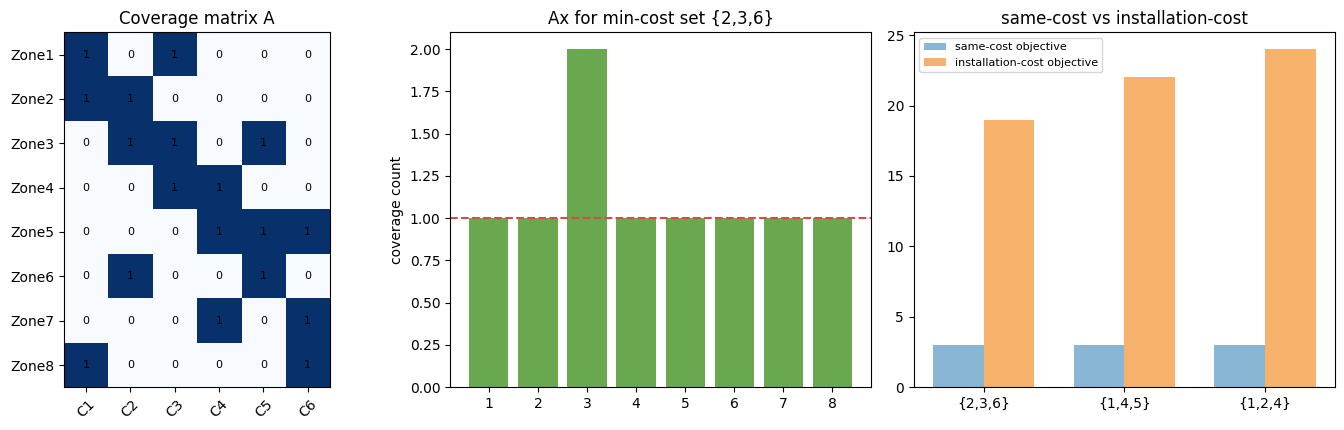

관찰: 세 조합은 모두 설치수 3인 동일비용 최적 후보지만, 설치비용은 {2,3,6}이 가장 낮다.
원인: set covering의 feasibility는 Ax>=1이 결정하고, 목적함수는 설치수 또는 비용 계수가 결정한다.
제한: 복수 최적해는 동일비용 목적에서 특히 자주 발생한다.
결론: covering은 중복 커버를 허용하므로 =1로 바꾸면 다른 문제가 된다.


In [1]:
# 시각화 업데이트: 문제 1 set covering matrix, 동일비용/install cost 비교
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

A = np.array([
    [1,0,1,0,0,0],
    [1,1,0,0,0,0],
    [0,1,1,0,1,0],
    [0,0,1,1,0,0],
    [0,0,0,1,1,1],
    [0,1,0,0,1,0],
    [0,0,0,1,0,1],
    [1,0,0,0,0,1],
])
cost = np.array([8,7,6,9,5,6])
solutions = {
    "동일비용 최적 예: {2,3,6}": np.array([0,1,1,0,0,1]),
    "동일비용 최적 예: {1,4,5}": np.array([1,0,0,1,1,0]),
    "동일비용 최적 예: {1,2,4}": np.array([1,1,0,1,0,0]),
}
min_cost_x = solutions["동일비용 최적 예: {2,3,6}"]
summary = []
for name, x in solutions.items():
    summary.append({"조합":name, "설치수":int(x.sum()), "설치비용":int(cost@x), "Ax":(A@x).tolist()})
display(pd.DataFrame(summary))

fig, axes = plt.subplots(1, 3, figsize=(14,4.4))
axes[0].imshow(A, cmap="Blues", vmin=0, vmax=1)
axes[0].set_xticks(range(6), labels=[f"C{j}" for j in range(1,7)], rotation=45)
axes[0].set_yticks(range(8), labels=[f"Zone{i}" for i in range(1,9)])
axes[0].set_title("Coverage matrix A")
for i in range(8):
    for j in range(6): axes[0].text(j,i,str(A[i,j]),ha="center",va="center",fontsize=8)

count = A @ min_cost_x
axes[1].bar(range(1,9), count, color=["#6aa84f" if c>=1 else "#d9d9d9" for c in count])
axes[1].axhline(1, color="#d84a4a", ls="--")
axes[1].set_xticks(range(1,9))
axes[1].set_title("Ax for min-cost set {2,3,6}")
axes[1].set_ylabel("coverage count")

labels = ["{2,3,6}", "{1,4,5}", "{1,2,4}"]
counts = [3,3,3]
costs = [19,22,24]
x = np.arange(len(labels))
axes[2].bar(x-0.18, counts, width=0.36, label="same-cost objective", color="#8ab6d6")
axes[2].bar(x+0.18, costs, width=0.36, label="installation-cost objective", color="#f6b26b")
axes[2].set_xticks(x, labels=labels)
axes[2].set_title("same-cost vs installation-cost")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("관찰: 세 조합은 모두 설치수 3인 동일비용 최적 후보지만, 설치비용은 {2,3,6}이 가장 낮다.")
print("원인: set covering의 feasibility는 Ax>=1이 결정하고, 목적함수는 설치수 또는 비용 계수가 결정한다.")
print("제한: 복수 최적해는 동일비용 목적에서 특히 자주 발생한다.")
print("결론: covering은 중복 커버를 허용하므로 =1로 바꾸면 다른 문제가 된다.")


### 문제 2 정답 — 이동검진 버스 배치
**변수와 목적함수**
- `x_j=1`이면 후보지 `j` 운영, `0`이면 미운영.
- `y_i=1`이면 구역 `i`가 하나 이상의 운영 후보지로 혜택을 받음, `0`이면 미혜택.
- Maximize `5.0y1+7.5y2+4.0y3+6.5y4+8.0y5+3.5y6+9.0y7+4.5y8`.

**혜택 연결 제약**
- `y1 <= x1+x3`
- `y2 <= x1+x2`
- `y3 <= x2+x3+x5`
- `y4 <= x3+x4`
- `y5 <= x4+x5+x6`
- `y6 <= x2+x5`
- `y7 <= x4+x6`
- `y8 <= x1+x6`
- domain: `x_j, y_i in {0,1}`.

**추가 조건**
- 최대 3개: `x1+x2+x3+x4+x5+x6 <= 3`
- 후보지 1과 4 상호배타: `x1+x4 <= 1`
- 후보지 6 prerequisite: `x6 <= x4`
- 동부권 최소 하나: `x4+x5+x6 >= 1`

**검산 기준 최적해**
- 제공 데이터 기준 최적 운영 조합은 `{2,3,4}`이고 혜택 구역은 1~7, 총 혜택 인구는 `43.5`이다.
- 구역 8은 이 조합에서 커버되지 않는다.

**중복계산 오답 진단**
- `5.0(x1+x3)+...`처럼 coverage count에 인구를 곱하면 한 구역이 두 후보지로 커버될 때 같은 주민을 두 번 계산한다.
- `y_i`를 두면 `y_i`는 0 또는 1로만 계산되어 중복 혜택이 방지된다.
- set covering은 모든 구역 커버를 요구하고 보통 설치 수/비용을 최소화한다. max coverage는 설치 수가 제한되어 있을 때 커버된 혜택 합계를 최대화한다.


#### 문항별 시각화 학습자료 — 문제 2
- 시각화 목적: max coverage에서 `x_j` 설치와 `y_i` 혜택 변수가 왜 분리되는지 확인한다.
- 사용할 데이터: 문제 1의 coverage matrix와 구역별 인구.
- 그래프 해석 포인트: coverage count가 2 이상이어도 인구는 `y_i=1`로 한 번만 더한다.
- 학생이 자주 하는 오해: coverage count에 인구를 곱해 주민을 중복계산한다.
- 체크포인트 질문: 최적 조합에서 어떤 구역이 미커버이며, 왜 그래도 max coverage 해가 되는가?


,구역,인구,coverage_count,y_i,true_pop*y,wrong_pop*count
0,1,5.0,1,1,5.0,5.0
1,2,7.5,1,1,7.5,7.5
2,3,4.0,2,1,4.0,8.0
3,4,6.5,2,1,6.5,13.0
4,5,8.0,1,1,8.0,8.0
5,6,3.5,1,1,3.5,3.5
6,7,9.0,1,1,9.0,9.0
7,8,4.5,0,0,0.0,0.0


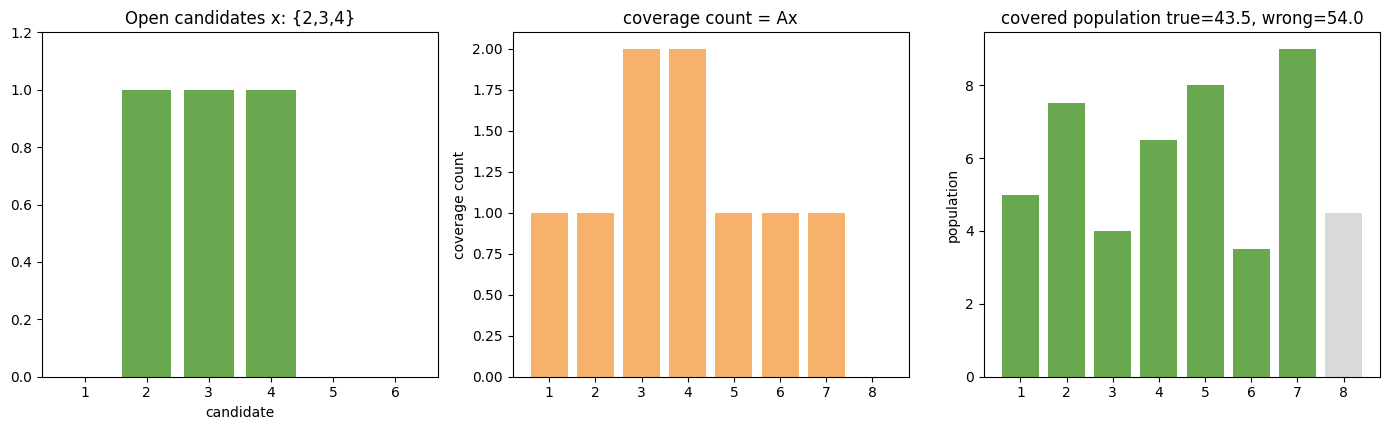

관찰: 구역 8은 미커버이고, 나머지 1~7은 혜택 y_i=1이다.
원인: 후보지 수 제한과 논리조건 때문에 모든 구역을 덮는 대신 혜택 인구를 최대화한다.
제한: wrong_pop*count는 같은 구역이 여러 번 커버되면 주민을 중복해서 센다.
결론: max coverage는 x_j와 y_i를 분리하고 y_i <= sum_j A_ij x_j로 연결해야 한다.


In [2]:
# 시각화 업데이트: 문제 2 max coverage 최적 조합과 중복계산 진단
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

A = np.array([
    [1,0,1,0,0,0],
    [1,1,0,0,0,0],
    [0,1,1,0,1,0],
    [0,0,1,1,0,0],
    [0,0,0,1,1,1],
    [0,1,0,0,1,0],
    [0,0,0,1,0,1],
    [1,0,0,0,0,1],
])
pop = np.array([5.0,7.5,4.0,6.5,8.0,3.5,9.0,4.5])
x_opt = np.array([0,1,1,1,0,0])  # {2,3,4}
count = A @ x_opt
y = (count >= 1).astype(int)
true_value = float(pop @ y)
wrong_value = float(pop @ count)

df = pd.DataFrame({"구역":range(1,9), "인구":pop, "coverage_count":count, "y_i":y, "true_pop*y":pop*y, "wrong_pop*count":pop*count})
display(df)

fig, axes = plt.subplots(1, 3, figsize=(14,4.4))
axes[0].bar(range(1,7), x_opt, color=["#6aa84f" if v else "#d9d9d9" for v in x_opt])
axes[0].set_xticks(range(1,7))
axes[0].set_ylim(0,1.2)
axes[0].set_title("Open candidates x: {2,3,4}")
axes[0].set_xlabel("candidate")

axes[1].bar(range(1,9), count, color="#f6b26b")
axes[1].set_xticks(range(1,9))
axes[1].set_title("coverage count = Ax")
axes[1].set_ylabel("coverage count")

axes[2].bar(range(1,9), pop, color=["#6aa84f" if yy else "#d9d9d9" for yy in y])
axes[2].set_xticks(range(1,9))
axes[2].set_title(f"covered population true={true_value:.1f}, wrong={wrong_value:.1f}")
axes[2].set_ylabel("population")
plt.tight_layout()
plt.show()

print("관찰: 구역 8은 미커버이고, 나머지 1~7은 혜택 y_i=1이다.")
print("원인: 후보지 수 제한과 논리조건 때문에 모든 구역을 덮는 대신 혜택 인구를 최대화한다.")
print("제한: wrong_pop*count는 같은 구역이 여러 번 커버되면 주민을 중복해서 센다.")
print("결론: max coverage는 x_j와 y_i를 분리하고 y_i <= sum_j A_ij x_j로 연결해야 한다.")


### 문제 3 정답 — 소형 소방거점 입지와 배정
**변수와 목적함수**
- `y_j=1`이면 후보지 `j`를 열고, `0`이면 열지 않는다.
- `x_ij=1`이면 구역 `i`를 후보지 `j`에 배정한다.
- Minimize `100y1+85y2+90y3+70y4 + sum_i sum_j demand_i*c_ij*x_ij`.

**제약식**
- 각 구역 정확히 하나 배정: `sum_j x_ij = 1` for all `i`.
- 열린 후보지에만 배정: `x_ij <= y_j` for all `i,j`.
- 설치 가능성 제한: `x_ij <= a_ij`; `a_ij=0`이면 `x_ij=0`.
- 용량: `sum_i demand_i*x_i1 <= 60y1`, `sum_i demand_i*x_i2 <= 55y2`, `sum_i demand_i*x_i3 <= 70y3`, `sum_i demand_i*x_i4 <= 45y4`.
- 최소 2개 개방: `y1+y2+y3+y4 >= 2`.
- domain: `x_ij, y_j in {0,1}`.

**검산 기준 최적해**
- 제공 데이터 기준 최적 개방 조합은 `{1,3,4}`이다.
- 한 최적 배정은 구역 1->3, 2->1, 3->3, 4->3, 5->4, 6->4이다.
- 후보지별 load는 `(25, 0, 65, 40)`이고 총비용은 `866`이다.

**모형 성격과 오답 진단**
- fixed-charge: 후보지를 열면 고정비가 든다.
- facility location: 어느 후보지를 열지 결정한다.
- assignment: 각 구역을 정확히 하나의 열린 후보지에 배정한다.
- set covering과 유사하게 가능성 행렬을 쓰지만, `Ax>=1`만으로는 정확히 하나 배정, 용량, 개방-배정 연결을 표현할 수 없다.
- `x_ij <= y_j`가 없으면 닫힌 후보지에 구역이 배정될 수 있다.
- branch-and-bound가 필요한 이유는 `x_ij`와 `y_j`가 모두 binary라서 연속 LP처럼 단순히 나누어 배정할 수 없기 때문이다.

**source anchor / node_id**
- anchors: `DM_PDF08:p001:L002`, `DM_PDF08:p001:L004`, `DM_PDF08:p002:L003`, `DM_PDF08:p002:L005`, `DM_PDF08:p002:L007`, `DM_PDF08:p004:L003`, `DM_PDF08:p004:L007`, `DM_PDF08:p004:L008`, `DM_PDF08:p006:L003`, `DM_PDF08:p006:L006`, `DM_PDF08:p006:L007`, `DM_PDF08:p006:L008`, `DM_PDF08:p007:L009`, `DM_PDF08:p010:L002`, `DM_PDF08:p011:L002`, `DM_PDF08:p012:L002`, `DM_PDF04:p021:L002`, `DM_PDF04:p025:L002`, `DM_PDF04:p026:L002`, `DM_PDF03:p001:L001`
- node_id: `n_DM_PDF08.set_covering_model`, `n_DM_PDF08.facility_location`, `n_DM_PDF08.coverage_matrix`, `n_DM_PDF08.set_covering_partitioning_packing`, `n_DM_PDF08.benefit_max_variant`, `n_DM_PDF08.wrong_model_diagnosis`, `n_DM_PDF08.binary_open_variable`, `n_DM_PDF04.fixed_charge_model`, `n_DM_PDF06.assignment_problem`, `n_DM_PDF03.branch_and_bound`


#### 문항별 시각화 학습자료 — 문제 3
- 시각화 목적: open 변수, assignment 변수, availability, capacity가 함께 작동하는 방식을 본다.
- 사용할 데이터: 소방거점 고정비, 용량, 수요, 배정비, 설치 가능성 제한.
- 그래프 해석 포인트: 열린 후보지에만 배정되고, 후보지별 load가 capacity를 넘지 않는다.
- 학생이 자주 하는 오해: `Ax>=1`만 쓰면 배정과 용량까지 해결된다고 생각한다.
- 체크포인트 질문: `x_ij <= y_j`와 `capacity_j*y_j`가 빠지면 어떤 비현실적 해가 가능한가?


,구역,수요,배정 후보지,단위비용,배정비
0,1,20,3,5,100
1,2,25,1,4,100
2,3,15,3,6,90
3,4,30,3,4,120
4,5,18,4,6,108
5,6,22,4,4,88


,후보지,open_y,load,capacity,fixed_cost
0,1,1,25,60,100
1,2,0,0,55,85
2,3,1,65,70,90
3,4,1,40,45,70


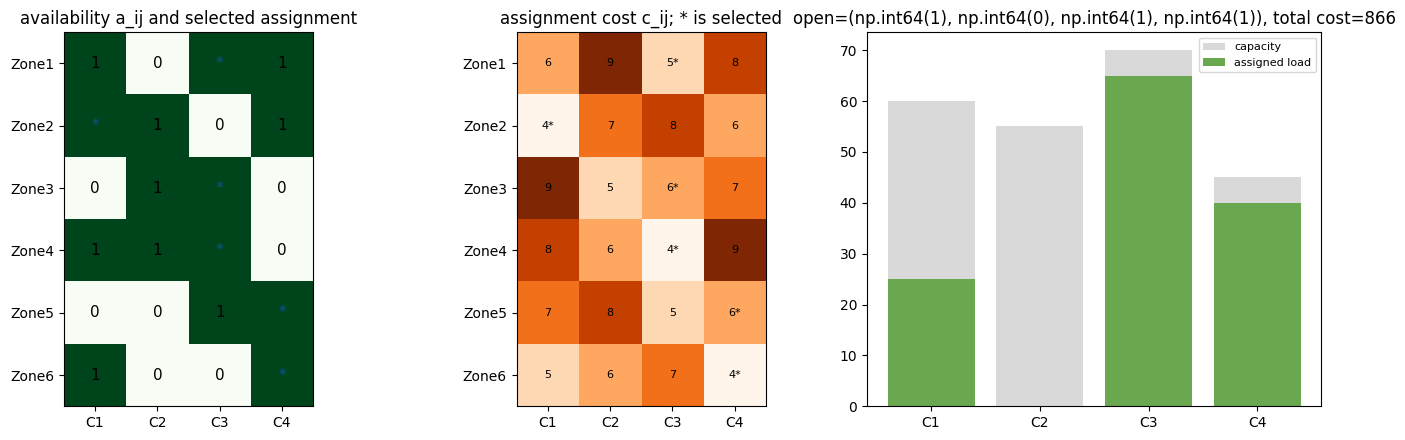

관찰: 후보지 2는 닫혀 있으므로 load=0이고, 열린 후보지 1/3/4에만 배정된다.
원인: x_ij <= y_j와 capacity_j*y_j가 assignment와 open 결정을 연결한다.
제한: Ax>=1은 커버 여부만 말하므로 정확히 하나 배정과 용량을 보장하지 못한다.
결론: 이 문제는 assignment + facility location + fixed-charge + capacity가 결합된 0-1 정수계획이다.


In [3]:
# 시각화 업데이트: 문제 3 capacitated facility location 최적 배정 보드
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

D = np.array([20,25,15,30,18,22])
fixed = np.array([100,85,90,70])
cap = np.array([60,55,70,45])
cost = np.array([
    [6,9,5,8],
    [4,7,8,6],
    [9,5,6,7],
    [8,6,4,9],
    [7,8,5,6],
    [5,6,7,4],
])
avail = np.array([
    [1,0,1,1],
    [1,1,0,1],
    [0,1,1,0],
    [1,1,1,0],
    [0,0,1,1],
    [1,0,0,1],
])
y_opt = np.array([1,0,1,1])  # 후보지 {1,3,4}
assign = np.array([2,0,2,2,3,3])  # 0-index: 구역1->후보3, 구역2->후보1, ...
X = np.zeros((6,4), dtype=int)
for i,j in enumerate(assign): X[i,j]=1
load = D @ X
variable_cost = int(sum(D[i]*cost[i,assign[i]] for i in range(6)))
total = int(fixed @ y_opt + variable_cost)

df = pd.DataFrame({"구역":range(1,7), "수요":D, "배정 후보지":[j+1 for j in assign], "단위비용":[cost[i,assign[i]] for i in range(6)], "배정비":[D[i]*cost[i,assign[i]] for i in range(6)]})
display(df)
display(pd.DataFrame({"후보지":range(1,5), "open_y":y_opt, "load":load, "capacity":cap, "fixed_cost":fixed}))

fig, axes = plt.subplots(1, 3, figsize=(14,4.5))
axes[0].imshow(avail, cmap="Greens", vmin=0, vmax=1)
axes[0].set_xticks(range(4), labels=[f"C{j}" for j in range(1,5)])
axes[0].set_yticks(range(6), labels=[f"Zone{i}" for i in range(1,7)])
axes[0].set_title("availability a_ij and selected assignment")
for i in range(6):
    for j in range(4):
        mark = "*" if X[i,j] else str(avail[i,j])
        axes[0].text(j,i,mark,ha="center",va="center",fontsize=11, color="#0b5394" if X[i,j] else "black")

im = axes[1].imshow(cost, cmap="Oranges")
axes[1].set_xticks(range(4), labels=[f"C{j}" for j in range(1,5)])
axes[1].set_yticks(range(6), labels=[f"Zone{i}" for i in range(1,7)])
axes[1].set_title("assignment cost c_ij; * is selected")
for i in range(6):
    for j in range(4):
        txt = f"{cost[i,j]}" + ("*" if X[i,j] else "")
        axes[1].text(j,i,txt,ha="center",va="center",fontsize=8)

x = np.arange(4)
axes[2].bar(x, cap, color="#d9d9d9", label="capacity")
axes[2].bar(x, load, color=["#6aa84f" if y else "#b7b7b7" for y in y_opt], label="assigned load")
axes[2].set_xticks(x, labels=[f"C{j}" for j in range(1,5)])
axes[2].set_title(f"open={tuple(y_opt)}, total cost={total}")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("관찰: 후보지 2는 닫혀 있으므로 load=0이고, 열린 후보지 1/3/4에만 배정된다.")
print("원인: x_ij <= y_j와 capacity_j*y_j가 assignment와 open 결정을 연결한다.")
print("제한: Ax>=1은 커버 여부만 말하므로 정확히 하나 배정과 용량을 보장하지 못한다.")
print("결론: 이 문제는 assignment + facility location + fixed-charge + capacity가 결합된 0-1 정수계획이다.")


## 3. 채점 기준
| 항목 | 배점 | 부분점 기준 |
|---|---:|---|
| coverage matrix와 0-1 변수 정의 | 20 | 행/열 인덱스 뒤집으면 감점 |
| set covering/partitioning/packing 부등호 해석 | 20 | `>=`, `=`, `<=` 의미를 현실 문장으로 설명 |
| max coverage x/y 변수 분리 | 25 | `y_i <= sum A_ij x_j`와 binary domain 필수 |
| capacitated facility location formulation | 25 | assignment, open, capacity, availability 모두 필요 |
| Solver mapping, B&B 연결, source anchor/node_id | 10 | 셀 구조와 정수해 탐색 필요성 설명 |

## 4. 오답튜터 기준표
| 오류 | 진단 질문 | 교정 힌트 |
|---|---|---|
| covering을 partitioning처럼 `=1`로 씀 | “중복 커버가 왜 금지되어야 하는가?” | covering은 보통 `>=1`이다. |
| set packing과 covering 부등호 뒤집음 | “최소 하나인가, 최대 하나인가?” | cover는 `>=1`, pack은 `<=1`이다. |
| coverage matrix 행/열 인덱스 뒤집음 | “행이 구역인가 후보지인가?” | `i`는 수요구역, `j`는 후보지로 고정한다. |
| max coverage 중복계산 | “같은 주민을 두 번 세고 있나?” | 혜택 변수 `y_i`로 한 번만 계산한다. |
| `y_i <= sum A_ij x_j` 누락 | “커버되지 않은 구역도 혜택 1이 될 수 있는가?” | 혜택과 설치를 연결한다. |
| open 변수와 assignment 변수 미분리 | “시설을 열었는가와 배정했는가가 같은가?” | `y_j`와 `x_ij`를 분리한다. |
| `x_ij <= y_j` 누락 | “닫힌 시설에 배정 가능한가?” | 열린 후보지에만 배정한다. |
| capacity에서 `capacity_j*y_j` 누락 | “닫혔을 때 용량이 0인가?” | 용량도 open 변수와 연결한다. |
| binary domain 누락 | “0.4개 시설 설치가 가능한가?” | 모든 선택/배정 변수에 binary 지정. |
| coverage count cells와 objective cells 혼동 | “행별 커버 수와 전체 목적값이 같은 셀인가?” | 중간 계산 셀과 목표셀을 분리한다. |

## 5. 다음 Phase 연결
- 다음 주제는 nonlinear programming, GRG, local/global optimum으로 넘어간다.
- 0-1 모형에서는 불연속 선택을 branch-and-bound로 다뤘지만, 비선형 모형에서는 곡면의 지역 최적성과 초기해 민감도가 핵심이 된다.
